[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/notebooks/learning-guides/03-supervisado-no-supervisado.ipynb)


# Machine Learning: Aprendizaje Supervisado y No Supervisado

**Notebook para Google Colab**

Este notebook toma como base el material de clase **“MACHINE LEARNING”** y lo convierte en una guía práctica con explicaciones, ejemplos y código ejecutable.

## Objetivos

Al finalizar este notebook podrás:

1. Entender la relación entre **Inteligencia Artificial, Machine Learning y Deep Learning**.
2. Comprender la definición de aprendizaje de **Tom M. Mitchell** usando:
   - **Tarea (T)**
   - **Rendimiento (P)**
   - **Experiencia (E)**
3. Diferenciar **aprendizaje supervisado** y **no supervisado**.
4. Reconocer problemas de:
   - Clasificación
   - Regresión
   - Clustering
   - Reducción de dimensionalidad
   - Detección de anomalías
5. Entrenar modelos sencillos con `scikit-learn`.
6. Evaluar e interpretar sus resultados.

> **Fuente base:** material de clase “MACHINE LEARNING.pdf”.  
> **Nota:** los ejemplos de programación son una ampliación práctica para trabajar los conceptos en Google Colab.



## 1. Contextualización

El material presenta una relación jerárquica:

**Inteligencia Artificial → Machine Learning → Deep Learning**

### Inteligencia Artificial
Busca desarrollar sistemas capaces de realizar tareas asociadas con comportamientos inteligentes.

### Machine Learning
Es un subconjunto de la Inteligencia Artificial que utiliza métodos estadísticos y computacionales para que una máquina pueda **aprender a partir de datos y experiencia**.

### Deep Learning
Es un subconjunto de Machine Learning basado principalmente en **redes neuronales con múltiples capas**.



## 2. ¿Qué significa que una máquina “aprende”?

Tom M. Mitchell propone una definición clásica:

> Un programa aprende de la **experiencia E**, con respecto a una clase de **tareas T** y una medida de **rendimiento P**, si su desempeño en las tareas T, medido por P, mejora con la experiencia E.

### Componentes

- **Tarea (T):** problema que debe resolver el sistema.
- **Rendimiento (P):** métrica utilizada para medir qué tan bien realiza la tarea.
- **Experiencia (E):** datos o interacción con el entorno a partir de los cuales aprende.

### Ejemplo del material: detección de SPAM

- **T:** clasificar correos como `"spam"` o `"no spam"`.
- **P:** porcentaje de correos clasificados correctamente.
- **E:** conjunto de correos previamente etiquetados como spam o no spam.

Si después de entrenar con muchos ejemplos el porcentaje de aciertos aumenta, se considera que el programa **ha aprendido**.


In [ ]:

# Representación sencilla de T, P y E

T = "Clasificar correos electrónicos como spam o no spam"
P = "Porcentaje de correos clasificados correctamente"
E = "Conjunto de correos históricos etiquetados"

print("Tarea (T):", T)
print("Rendimiento (P):", P)
print("Experiencia (E):", E)


Tarea (T): Clasificar correos electrónicos como spam o no spam
Rendimiento (P): Porcentaje de correos clasificados correctamente
Experiencia (E): Conjunto de correos históricos etiquetados



## 3. Algunas aplicaciones de Machine Learning

### Medicina

El material menciona aplicaciones como:

- **Diagnóstico por imagen:** análisis de radiografías, resonancias o tomografías.
- **Descubrimiento de fármacos:** análisis de interacciones entre moléculas y proteínas.
- **Medicina personalizada:** recomendación de tratamientos según el perfil del paciente.
- **Predicción de epidemias:** análisis de múltiples fuentes de información para anticipar brotes.

### Finanzas

Entre los ejemplos presentados se encuentran:

- **Detección de fraudes**
- **Trading algorítmico**
- **Evaluación de riesgo crediticio**
- **Detección de lavado de dinero**



# 4. Aprendizaje Supervisado

En el **aprendizaje supervisado**, el algoritmo aprende a partir de datos **etiquetados**.

Cada observación de entrenamiento contiene:

- unas variables de entrada o características (**X**),
- una respuesta conocida o etiqueta (**y**).

El objetivo es aprender una función que permita predecir la salida de **nuevos datos no vistos**.

## Principales tipos

### 4.1 Clasificación
La salida es una **categoría discreta**.

Ejemplos:

- Spam / No spam
- Gato / Perro
- Tumor benigno / maligno

### 4.2 Regresión
La salida es un **valor numérico continuo**.

Ejemplos:

- Precio de una casa
- Temperatura
- Ventas del próximo mes



## 5. Ejemplo práctico de clasificación

Usaremos el conjunto de datos de cáncer de mama incluido en `scikit-learn`.

> Este ejercicio es una **ampliación práctica** del concepto de clasificación supervisada presentado en el material.

El objetivo será predecir una de dos clases a partir de variables numéricas.


In [ ]:

# Librerías principales

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [ ]:

# Cargar datos

data_clf = load_breast_cancer()

X_clf = pd.DataFrame(data_clf.data, columns=data_clf.feature_names)
y_clf = pd.Series(data_clf.target, name="clase")

print("Dimensión de X:", X_clf.shape)
print("Número de clases:", y_clf.nunique())

display(X_clf.head())


Dimensión de X: (569, 30)
Número de clases: 2


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:

# Separar entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (455, 30)
Prueba: (114, 30)


In [ ]:

# Escalar las variables y entrenar una Regresión Logística

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_clf = LogisticRegression(max_iter=2000)
modelo_clf.fit(X_train_scaled, y_train)

pred_clf = modelo_clf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, pred_clf)

print(f"Accuracy: {accuracy:.4f}")
print("\nReporte de clasificación:\n")
print(classification_report(y_test, pred_clf, target_names=data_clf.target_names))


Accuracy: 0.9825

Reporte de clasificación:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



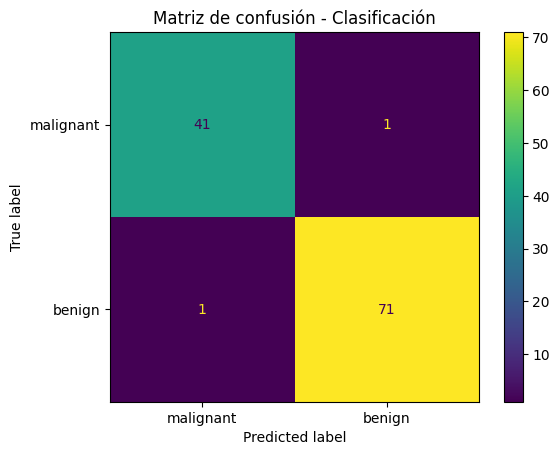

In [ ]:

# Matriz de confusión

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_clf,
    display_labels=data_clf.target_names
)

plt.title("Matriz de confusión - Clasificación")
plt.show()



### Interpretación

En este ejemplo:

- **Tarea (T):** predecir la clase de una observación.
- **Rendimiento (P):** `accuracy` y otras métricas de clasificación.
- **Experiencia (E):** datos utilizados durante el entrenamiento.

La matriz de confusión permite observar cuántos casos fueron clasificados correctamente y cuántos fueron confundidos con la otra clase.



## 6. Ejemplo práctico de regresión

Ahora trabajaremos con un problema donde la variable objetivo es **numérica continua**.

Usaremos el conjunto `diabetes` de `scikit-learn` para mostrar el funcionamiento básico de una regresión lineal.

> El objetivo aquí es practicar el concepto de **regresión supervisada**.


In [ ]:

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data_reg = load_diabetes()

X_reg = pd.DataFrame(data_reg.data, columns=data_reg.feature_names)
y_reg = pd.Series(data_reg.target, name="objetivo")

display(X_reg.head())
print("Dimensión:", X_reg.shape)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Dimensión: (442, 10)


In [ ]:

# División de datos

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Entrenamiento

modelo_reg = LinearRegression()
modelo_reg.fit(X_train_reg, y_train_reg)

# Predicción

pred_reg = modelo_reg.predict(X_test_reg)

# Métricas

mae = mean_absolute_error(y_test_reg, pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, pred_reg))
r2 = r2_score(y_test_reg, pred_reg)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


MAE : 42.79
RMSE: 53.85
R²  : 0.4526


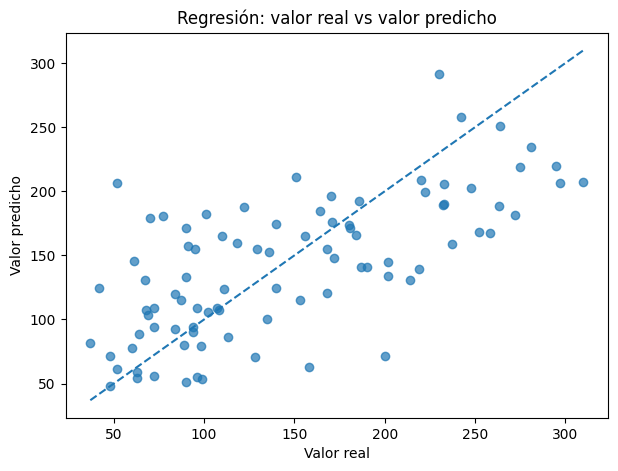

In [ ]:

# Valores reales vs valores predichos

plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, pred_reg, alpha=0.7)

min_val = min(y_test_reg.min(), pred_reg.min())
max_val = max(y_test_reg.max(), pred_reg.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Regresión: valor real vs valor predicho")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.show()



### Métricas utilizadas en regresión

- **MAE:** error absoluto medio.
- **RMSE:** raíz del error cuadrático medio.
- **R²:** proporción de variabilidad explicada por el modelo.

En regresión no buscamos asignar una categoría, sino aproximar un **valor continuo**.



# 7. Aprendizaje No Supervisado

En el **aprendizaje no supervisado** los datos **no tienen una respuesta correcta o etiqueta conocida**.

El algoritmo busca descubrir estructuras internas, patrones o agrupaciones dentro de los datos.

El material presenta tres enfoques importantes:

### 7.1 Clustering o agrupamiento
Agrupar observaciones de manera que los elementos dentro de un mismo grupo sean similares entre sí y diferentes a los de otros grupos.

### 7.2 Reducción de dimensionalidad
Reducir el número de variables intentando conservar la información más importante.

### 7.3 Detección de anomalías
Identificar observaciones inusualmente diferentes del resto de los datos.



## 8. Ejemplo práctico de Clustering con K-Means

Construiremos datos artificiales para visualizar con claridad cómo un algoritmo puede encontrar grupos **sin recibir etiquetas de clase durante el entrenamiento**.


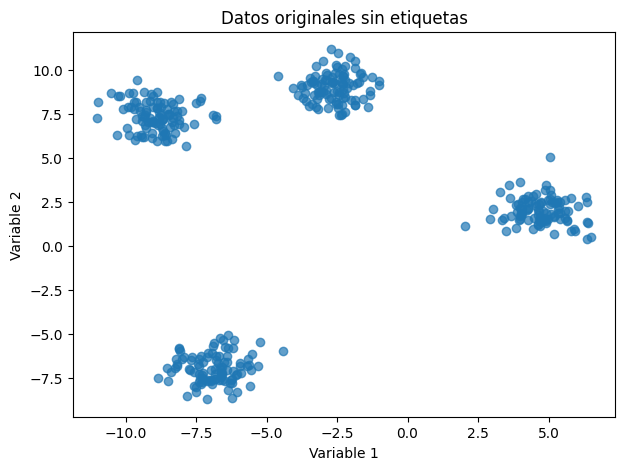

In [ ]:

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Crear datos artificiales
X_cluster, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=0.80,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], alpha=0.7)
plt.title("Datos originales sin etiquetas")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.show()


In [ ]:

# Entrenar K-Means

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)

print("Primeras asignaciones de cluster:")
print(clusters[:20])

print(f"\nSilhouette Score: {silhouette_score(X_cluster, clusters):.4f}")


Primeras asignaciones de cluster:
[3 1 3 0 0 1 1 3 1 0 3 0 3 0 2 2 2 1 0 2]

Silhouette Score: 0.8350


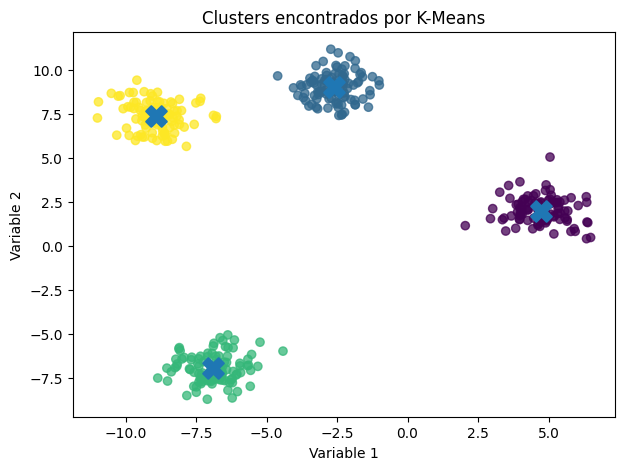

In [ ]:

# Visualizar agrupamientos encontrados

plt.figure(figsize=(7, 5))
plt.scatter(
    X_cluster[:, 0],
    X_cluster[:, 1],
    c=clusters,
    alpha=0.75
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=220,
    linewidths=1.5
)

plt.title("Clusters encontrados por K-Means")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.show()



### Interpretación

K-Means no recibió una columna que indicara a qué grupo pertenecía cada observación.

El algoritmo analizó la estructura de los datos y creó agrupaciones según la cercanía entre los puntos.



## 9. Reducción de dimensionalidad con PCA

El material explica que la reducción de dimensionalidad busca **simplificar los datos reduciendo el número de variables**, procurando conservar la información relevante.

Usaremos **PCA (Principal Component Analysis)** para transformar un conjunto con cuatro variables en solo dos componentes principales.


In [ ]:

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

iris = load_iris()

X_pca_original = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print("Dimensión original:", X_pca_original.shape)
display(X_pca_original.head())


In [ ]:

# Estandarizar y reducir de 4 dimensiones a 2

X_pca_scaled = StandardScaler().fit_transform(X_pca_original)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_scaled)

print("Dimensión después de PCA:", X_pca.shape)
print("\nVarianza explicada por componente:")
print(pca.explained_variance_ratio_)
print("\nVarianza explicada acumulada:")
print(pca.explained_variance_ratio_.cumsum())


In [ ]:

# Visualización 2D

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.75
)

plt.title("Reducción de dimensionalidad con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()



### ¿Qué ocurrió?

Los datos originales tenían **4 variables**. PCA los representó mediante **2 componentes principales**.

Esto puede ser útil para:

- visualizar información de alta dimensión,
- disminuir redundancia,
- simplificar modelos,
- reducir ruido,
- preparar datos para otros algoritmos.



## 10. Detección de anomalías

Una anomalía es una observación que se comporta de manera muy diferente al resto.

Ejemplos mencionados en el material:

- Transacciones fraudulentas.
- Fallos en una línea de producción.
- Intrusiones en una red informática.

A continuación utilizaremos `IsolationForest` para detectar puntos atípicos en datos artificiales.


In [ ]:

from sklearn.ensemble import IsolationForest

rng = np.random.RandomState(42)

# Datos normales
normales = rng.normal(loc=0, scale=1.0, size=(250, 2))

# Algunos puntos claramente alejados
anomalias = rng.uniform(low=-6, high=6, size=(20, 2))

X_anom = np.vstack([normales, anomalias])

modelo_anom = IsolationForest(
    contamination=20/270,
    random_state=42
)

pred_anom = modelo_anom.fit_predict(X_anom)

# 1 = normal, -1 = anomalía
resultado = np.where(pred_anom == -1, "Anomalía", "Normal")

pd.Series(resultado).value_counts()


,count
Normal,250
Anomalía,20


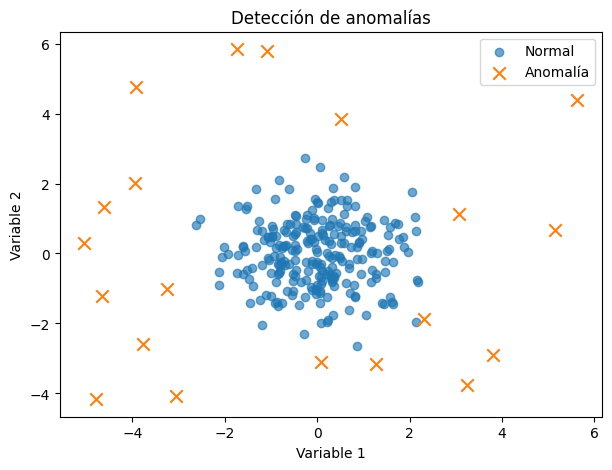

In [ ]:

# Visualización

plt.figure(figsize=(7, 5))

plt.scatter(
    X_anom[pred_anom == 1, 0],
    X_anom[pred_anom == 1, 1],
    alpha=0.65,
    label="Normal"
)

plt.scatter(
    X_anom[pred_anom == -1, 0],
    X_anom[pred_anom == -1, 1],
    marker="x",
    s=80,
    label="Anomalía"
)

plt.title("Detección de anomalías")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.legend()
plt.show()



# 11. Comparación: Supervisado vs No Supervisado

| Característica | Supervisado | No supervisado |
|---|---|---|
| ¿Tiene etiquetas? | Sí | No |
| Objetivo | Predecir una salida conocida | Descubrir estructura o patrones |
| Ejemplos principales | Clasificación y regresión | Clustering, PCA y anomalías |
| Variable objetivo `y` | Existe | Generalmente no existe |
| Ejemplo | Spam / No spam | Segmentación de clientes |
| Evaluación | Accuracy, F1, MAE, RMSE, R², etc. | Silhouette, varianza explicada, interpretación, etc. |

## Regla rápida

- Si tengo una **respuesta conocida** que quiero predecir → **Supervisado**.
- Si quiero **explorar patrones sin una respuesta conocida** → **No supervisado**.



# 12. Ejercicio de identificación

Clasifica cada problema como **supervisado** o **no supervisado** e indica el subtipo.

1. Predecir si una transacción es fraudulenta usando datos históricos etiquetados.
2. Agrupar clientes según su comportamiento de compra.
3. Predecir el precio de una vivienda.
4. Reducir 100 variables de sensores a 10 componentes.
5. Clasificar una imagen como gato o perro.
6. Encontrar observaciones extrañas en una red informática sin etiquetas previas.


In [ ]:

# Respuestas sugeridas

respuestas = pd.DataFrame({
    "Problema": [
        "Fraude con datos etiquetados",
        "Segmentación de clientes",
        "Precio de vivienda",
        "Reducir variables",
        "Gato o perro",
        "Puntos extraños sin etiquetas"
    ],
    "Tipo": [
        "Supervisado",
        "No supervisado",
        "Supervisado",
        "No supervisado",
        "Supervisado",
        "No supervisado"
    ],
    "Subtipo": [
        "Clasificación",
        "Clustering",
        "Regresión",
        "Reducción de dimensionalidad",
        "Clasificación",
        "Detección de anomalías"
    ]
})

display(respuestas)


,Problema,Tipo,Subtipo
0,Fraude con datos etiquetados,Supervisado,Clasificación
1,Segmentación de clientes,No supervisado,Clustering
2,Precio de vivienda,Supervisado,Regresión
3,Reducir variables,No supervisado,Reducción de dimensionalidad
4,Gato o perro,Supervisado,Clasificación
5,Puntos extraños sin etiquetas,No supervisado,Detección de anomalías



# 13. Resumen final

## Machine Learning

Un sistema aprende cuando su rendimiento en una tarea mejora gracias a la experiencia disponible.

### Aprendizaje supervisado
Trabaja con datos etiquetados.

- **Clasificación:** predice categorías.
- **Regresión:** predice valores numéricos.

### Aprendizaje no supervisado
Trabaja con datos sin etiquetas.

- **Clustering:** encuentra grupos.
- **Reducción de dimensionalidad:** simplifica la representación de los datos.
- **Detección de anomalías:** encuentra casos inusuales.

## Idea central

Antes de elegir un algoritmo, debemos preguntarnos:

> **¿Tengo una variable objetivo conocida que deseo predecir?**

- **Sí:** probablemente necesito aprendizaje supervisado.
- **No:** probablemente necesito aprendizaje no supervisado.



## 14. Reto opcional

Prueba realizar alguno de estos cambios:

1. Modifica el número de clusters de K-Means de `4` a `3` o `5`.
2. Cambia el porcentaje de datos de prueba del modelo supervisado.
3. Observa qué sucede con las métricas.
4. Modifica `n_components` en PCA.
5. Cambia el parámetro `contamination` de `IsolationForest`.
6. Explica con tus palabras qué significan **T, P y E** en uno de los ejemplos anteriores.
